In [1]:
############ Cellule 1.1.1 #################

# Chargement des bibliothèques nécessaires :
#HTTP : permet d'envoyer des requêtes web pour télécharger les données financières.
# CSV : sert à lire et écrire des fichiers CSV.
#DataFrames : permet de manipuler les données sous forme de tableaux.
#Dates : utile pour définir et gérer proprement la période d'étude.

using HTTP, CSV, DataFrames, Dates

# Le module Statistics sera utilisé plus loin pour les calculs statistiques
#de base sur les rendements ou les prix.

using Statistics

#Plots servira à produire les graphiques de visualisation des séries de prix.

using Plots

# Création du dossier de sauvegarde des données.
# Si le dossier "data" n'existe pas encore, il est créé automatiquement.
#Cela permet d'organiser proprement les fichiers générés par le notebook.

DATADIR = "data"
isdir(DATADIR) || mkpath(DATADIR)

 #Liste des tickers au format attendu par la base de données Stooq.
  # Le suffixe ".US" est obligatoire pour identifier correctement
#les actions américaines sur cette plateforme.

TICKERS_STOOQ = ["AAPL.US", "MSFT.US", "AMZN.US", "GOOG.US", "META.US"]

 #Liste simplifiée des noms d'actifs qui sera utilisée dans le fichier final
 #et dans les traitements ultérieurs. Elle permet d'obtenir des intitulés
#plus courts et plus lisibles dans les tableaux et graphiques.

TICKERS = ["AAPL", "MSFT", "AMZN", "GOOG", "META"]

# Définition de la période d'étude.
  #Ici, on retient une fenêtre d'environ 10 ans, du 1er janvier 2015
#au 31 décembre 2025, afin de disposer d'un historique suffisamment long
#pour l'analyse empirique du portefeuille.

START_DATE = Date(2015, 1, 1)
END_DATE= Date(2025, 12, 31)

 #Construction du chemin du fichier CSV final qui contiendra
#les prix historiques téléchargés et nettoyés.

OUTFILE= joinpath(DATADIR, "prices_tech.csv")

 #Affichage d'informations de contrôle pour vérifier immédiatement
# la période choisie et l'emplacement du fichier de sortie.

println("Période: ", START_DATE, " -> ", END_DATE)
println("Fichier cible: ", OUTFILE)

Période: 2015-01-01 -> 2025-12-31
Fichier cible: data\prices_tech.csv


In [5]:
############# Cellule 1.1.2 ###########################

 #Nous allons construire une fonction qui télécharge les données journalières d'un actif financier
# depuis la base de données Stooq, puis les convertit en DataFrame exploitable.
function download_stooq_daily(ticker_stooq::String)

    #Construction de l’URL de requête vers Stooq.
    # lowercase(...): Stooq attend les tickers en minuscules
    # i=d : fréquence quotidienne (daily)
    url= "https://stooq.com/q/d/l/?s=$(lowercase(ticker_stooq))&i=d"

    #Envoi de la requête HTTP avec mécanisme de retry :
    # retry=true : active la tentative automatique
    # retries=3 : jusqu’à 3 tentatives en cas d’échec
    
      resp= HTTP.get(url; retry=true, retries=3)

    # Vérification du statut HTTP :
     #200 signifie que la requête a réussi.
    #Sinon, on arrête le programme avec un message explicite.
    
    if resp.status != 200
        error("Échec téléchargement Stooq $(ticker_stooq). HTTP status=$(resp.status)")
    end

    # Lecture du contenu CSV renvoyé par Stooq directement depuis la réponse HTTP.
     #resp.body contient les données brutes
    # IOBuffer permet de traiter ces données comme un fichier
    
    df= CSV.read(IOBuffer(resp.body), DataFrame)

    #Détection automatique du nom de la colonne de date.
    #Selon les cas, Stooq peut utiliser "Date" ou "data".
    date_col = nothing
    for nm in names(df)
        if lowercase(String(nm)) == "date" || lowercase(String(nm)) == "data"
            date_col = nm
            break
        end
    end

    #Vérification que la colonne de date a bien été trouvée.
    # Sinon, on arrête avec un message d'erreur explicite.
    
    @assert date_col !== nothing "Colonne date introuvable. Colonnes disponibles: $(names(df))"

    #Renommage standard de la colonne en :Date pour homogénéiser les traitements futurs.
    rename!(df, date_col => :Date)

    #Conversion explicite de la colonne Date en type Date (Julia),
    #ce qui permet ensuite de faire des filtrages et tris temporels corrects.
    df.Date= Date.(df.Date)

    #La fonction retourne le DataFrame prêt à être utilisé.
    return df
end

download_stooq_daily (generic function with 1 method)

In [7]:
############### Cellule 1.1.3 ###########################

# Test de la fonction de téléchargement sur un actif réel (Apple).
  #Cette étape permet de vérifier que la fonction définie précédemment
 #fonctionne correctement avant de l’appliquer à l’ensemble des actifs.

println("Test téléchargement AAPL.US")

  #Appel de la fonction définie en Cellule 1.1.2.
#On récupère ici les données journalières de AAPL depuis Stooq.

df_test = download_stooq_daily("AAPL.US")

# Affichage des noms de colonnes du DataFrame obtenu.
 #Cela permet de vérifier la structure des données importées
  #(présence de Date, Open, High, Low, Close, Volume, etc.).

println("Colonnes détectées : ", names(df_test))

 #Nous allons maintenant les 5 premières lignes du DataFrame.
# Cette inspection rapide permet de valider :
   #- le bon téléchargement des données
   #- le format des dates
   #- la cohérence des valeurs numériques

first(df_test, 5)

Test téléchargement AAPL.US
Colonnes détectées : ["Date", "Open", "High", "Low", "Close", "Volume"]


Row,Date,Open,High,Low,Close,Volume
,Date,Float64,Float64,Float64,Float64,Int64
1,1984-09-07,0.0992653,0.100484,0.0980668,0.0992653,99149603
2,1984-09-10,0.0992653,0.0995698,0.0968786,0.098676,76956267
3,1984-09-11,0.0995698,0.102271,0.0995698,0.100484,181467446
4,1984-09-12,0.100484,0.101071,0.0974581,0.0974581,158527291
5,1984-09-13,0.10288,0.103173,0.10288,0.10288,246900394


In [9]:
############## Cellule 1.1.4 #################################

# Cette fonction construit un panel de prix à partir de plusieurs actifs.
#Pour chaque ticker :
    #1) on télécharge les données depuis Stooq ;
    #2) on restreint les observations à la période d'étude ;
    #3)on conserve uniquement la date et le prix de clôture ;
    #4) on renomme la colonne de clôture avec le nom propre de l'actif ;
    #5)on fusionne ensuite tous les actifs sur les dates communes.

function build_price_panel_stooq(tickers_stooq::Vector{String},
                                 tickers_clean::Vector{String},
                                 start_date::Date,
                                 end_date::Date)

    # Vérification de cohérence :
    # chaque ticker Stooq doit avoir un nom simplifié correspondant.
    @assert length(tickers_stooq) == length(tickers_clean)

    # Préallocation d'un vecteur de DataFrames.
    # Chaque case contiendra le sous-tableau Date + prix de clôture
    #d'un actif particulier.
    
    dfs = Vector{DataFrame}(undef, length(tickers_stooq))

    #Boucle sur tous les actifs à télécharger et préparer.
    for i in eachindex(tickers_stooq)

        #tkS : ticker au format Stooq (ex. AAPL.US)
        # tkC : nom simplifié qui servira comme nom de colonne final (ex. AAPL)
        tkS = tickers_stooq[i]
        tkC= tickers_clean[i]

        # Message d'information dans les logs pour suivre l'avancement
        #du téléchargement actif par actif.
        @info "Téléchargement" tkS

        # Téléchargement des données journalières de l'actif courant.
        df= download_stooq_daily(tkS)

         # Restriction à la fenêtre temporelle d'étude.
        #On ne conserve que les dates comprises entre start_date et end_date.
        df = df[(df.Date .>= start_date) .& (df.Date .<= end_date), :]

         # Vérification que la colonne de prix de clôture existe bien.
        #Cette colonne est essentielle pour construire le panel final.
        
        @assert "Close" in names(df) "Colonne Close absente pour $(tkS). Colonnes: $(names(df))"

          # On ne conserve que les informations strictement nécessaires :
        #la date et le prix de clôture.
        
        df_small = select(df, :Date, :Close)

        #La colonne Close est renommée avec le nom de l'actif
         #afin d'obtenir un panel final lisible, avec une colonne par action.
        
        rename!(df_small, :Close => Symbol(tkC))

        # Stockage du sous-tableau préparé dans le vecteur.
        dfs[i] = df_small
    end

    # Fusion progressive de tous les sous-tableaux.
     #On utilise ici une jointure interne (inner join), ce qui signifie
     #qe seules les dates communes à tous les actifs sont conservées.
    # Cela garantit un panel homogène sans dates manquantes entre actifs.
    
    merged = dfs[1]
    for i in 2:length(dfs)
        merged = innerjoin(merged, dfs[i], on=:Date)
    end

    # Tri final par ordre chronologique croissant.
    sort!(merged, :Date)

    # Le DataFrame final contient :
      #- une colonne Date
      #- une colonne de prix de clôture pour chacun des actifs.
    return merged
end

  #Construction effective du panel de prix sur la période d'étude définie plus haut.
     prices = build_price_panel_stooq(TICKERS_STOOQ, TICKERS, START_DATE, END_DATE)

#Affichage d'informations de contrôle sur la taille du panel obtenu :
  #- nrow : nombre de dates conservées
  #- ncol : nombre total de colonnes (Date + actifs)
@info "Panel final" nrow=nrow(prices) ncol=ncol(prices)

# Affichage des premières lignes pour vérifier visuellement
  #la structure du tableau final.
first(prices, 5)

┌ Info: Téléchargement
└   tkS = "AAPL.US"
┌ Info: Téléchargement
└   tkS = "MSFT.US"
┌ Info: Téléchargement
└   tkS = "AMZN.US"
┌ Info: Téléchargement
└   tkS = "GOOG.US"
┌ Info: Téléchargement
└   tkS = "META.US"
┌ Info: Panel final
│   nrow = 2766
└   ncol = 6


Row,Date,AAPL,MSFT,AMZN,GOOG,META
,Date,Float64,Float64,Float64,Float64,Float64
1,2015-01-02,24.2374,40.1536,15.426,26.2405,78.45
2,2015-01-05,23.5555,39.7826,15.1095,25.6935,77.19
3,2015-01-06,23.5575,39.1972,14.7645,25.098,76.15
4,2015-01-07,23.8917,39.6975,14.921,25.055,76.15
5,2015-01-08,24.8079,40.8676,15.023,25.134,78.18


In [11]:
############ cellule 1.1.5 ########################

  #Début du bloc de vérification de la qualité des données.
  #Cette étape est essentielle avant toute analyse financière,
   # afin de garantir la fiabilité des résultats obtenus par la suite.
println("-------------------------------------------------")
println("Vérifications (qualité des données)")
println("-------------------------------------------------")

  #Vérification que les dates sont bien triées dans l'ordre croissant.
  # Cela est indispensable pour les calculs de rendements et les analyses temporelles.

    @assert issorted(prices.Date) "Dates non triées !"

  #Affichage de la première et de la dernière date disponibles,
  # ce qui permet de vérifier rapidement la cohérence avec la période d’étude définie.
println("Date min :", minimum(prices.Date))
println("Date max :", maximum(prices.Date))

   #Nombre total d'observations (nombre de jours retenus dans le panel).
      println("Nombre d'observations :", nrow(prices))

# Boucle sur chaque actif pour vérifier la qualité des séries individuelles.
for tk in TICKERS

    # Conversion du nom de l'actif en symbole pour accéder à la colonne correspondante.
    col = Symbol(tk)

      # Comptage du nombre de valeurs manquantes (missing) dans la série.
    #En pratique, des données manquantes peuvent biaiser fortement les analyses.
    miss = count(ismissing, prices[!, col])
    println("Missing $(tk) :", miss)

    # Vérification stricte : aucune valeur manquante ne doit être présente.
    @assert miss == 0 "Valeurs manquantes détectées dans $(tk)"

    # Vérification économique : les prix doivent être strictement positifs.
    #Des valeurs nulles ou négatives seraient incohérentes pour des prix d'actifs.
    @assert all(prices[!, col] .> 0) "Prix non-positifs détectés dans $(tk)"
end

println("-------------------------------------------------")

-------------------------------------------------
Vérifications (qualité des données)
-------------------------------------------------
Date min :2015-01-02
Date max :2025-12-31
Nombre d'observations :2766
Missing AAPL :0
Missing MSFT :0
Missing AMZN :0
Missing GOOG :0
Missing META :0
-------------------------------------------------


In [15]:
#############Celule 1.1.6 ##############

  #Sauvegarde du DataFrame 'prices' dans un fichier CSV.
   #Cela permet de figer les données téléchargées et nettoyées,
 #afin de les réutiliser sans avoir à relancer tout le pipeline
  #de téléchargement et de préparation.

CSV.write(OUTFILE, prices)

#Message de confirmation pour indiquer que l'opération s'est bien déroulée
#et préciser l'emplacement du fichier sauvegardé.
println("CSV figé sauvegardé dans : ", OUTFILE)

CSV figé sauvegardé dans : data\prices_tech.csv


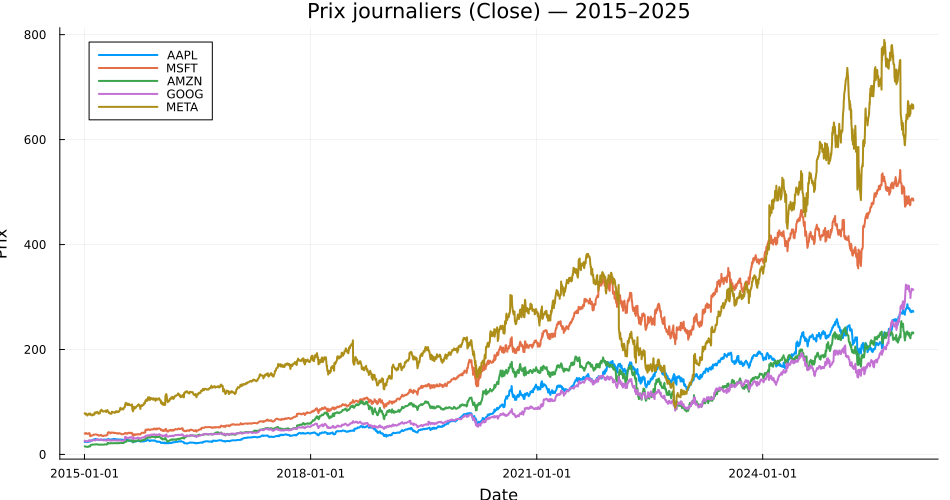

Figure sauvegardée : data\control_prices_2015_2025.png


In [17]:
######## Cellule 1.1.7 ###############

# Création d'un graphique vide avec paramètres globaux :
   # -titre explicite de la période étudiée
   # -labels des axes (Date, Prix)
   # -position de la légende
   # -taille de la figure pour une meilleure lisibilité
p_prices = plot(title="Prix journaliers (Close) — 2015–2025",
                xlabel="Date",
                ylabel="Prix",
                legend=:topleft,
                size=(950,500))

 #Ajout des courbes une par une pour chaque actif.
 #Chaque série correspond au prix de clôture d’un actif donné.
for tk in TICKERS

    #plot! permet d’ajouter une courbe au graphique existant
     #(le "!" signifie modification en place).
    plot!(p_prices,
          prices.Date,
          prices[!, Symbol(tk)],
          label=tk,
          linewidth=2)
end

# Affichage du graphique dans l’environnement de travail
display(p_prices)

 #Sauvegarde de la figure pour utilisation dans le rapport
 #ou pour une analyse ultérieure.
savefig(p_prices, joinpath(DATADIR, "control_prices_2015_2025.png"))

# Message de confirmation
println("Figure sauvegardée : ", joinpath(DATADIR, "control_prices_2015_2025.png"))

In [19]:
######### Cellule 1.1.8 ###

 #Fonction de calcul des rendements simples :
 # R_t = (P_t / P_{t-1}) - 1
  #Cette mesure représente le gain relatif entre deux dates consécutives.

simple_returns(p::AbstractVector{<:Real}) =
    p[2:end] ./ p[1:end-1] .- 1.0

#Fonction de calcul des log-rendements :
#r_t = log(P_t / P_{t-1})
# Les log-rendements sont additifs dans le temps et souvent utilisés
# en modélisation financière et en théorie du portefeuille.
log_returns(p::AbstractVector{<:Real}) =
    log.(p[2:end] ./ p[1:end-1])

log_returns (generic function with 1 method)

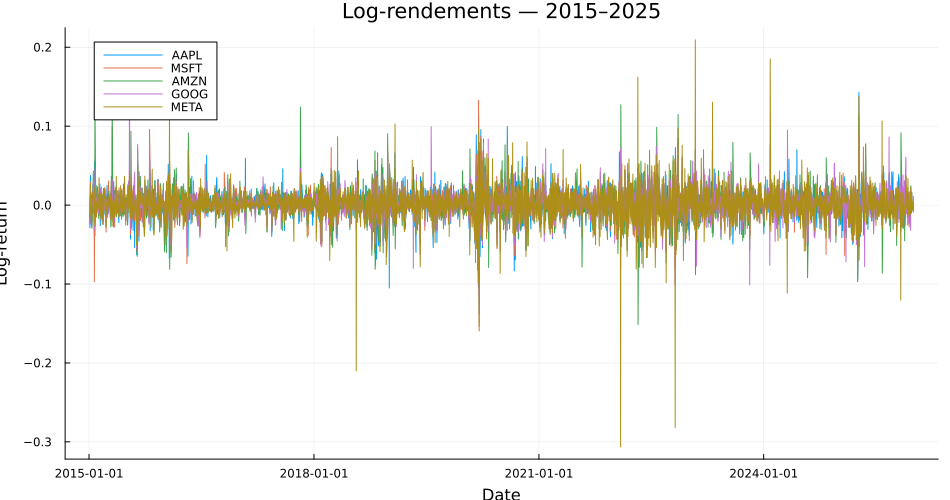

 Figure sauvegardée : data\control_log_returns_2015_2025.png
Volatilités annualisées (approx, 252 jours):


Row,Asset,Vol_Simple,Vol_Log
,String,Float64,Float64
1,AAPL,0.288378,0.288111
2,MSFT,0.268822,0.268562
3,AMZN,0.329292,0.328049
4,GOOG,0.288269,0.287618
5,META,0.37529,0.378402


In [21]:
######## Cellule 1.1.9#####

 #Ajustement des dates pour les rendements :
 #les rendements étant définis entre t-1 et t,
 # on perd la première observation.
dates_ret = prices.Date[2:end]

# --- Figure des log-rendements
  #Création du graphique global
p_log = plot(title="Log-rendements — 2015–2025",
             xlabel="Date",
             ylabel="Log-return",
             legend=:topleft,
             size=(950,500))

# Ajout des séries de log-rendements pour chaque actif
for tk in TICKERS
    r = log_returns(prices[!, Symbol(tk)])
    plot!(p_log, dates_ret, r, label=tk)
end

# Affichage et sauvegarde de la figure
display(p_log)
savefig(p_log, joinpath(DATADIR, "control_log_returns_2015_2025.png"))
println(" Figure sauvegardée : ", joinpath(DATADIR, "control_log_returns_2015_2025.png"))

  # Calcul des volatilités annualisées
#Hypothèse standard : 252 jours de trading par an
FREQ =252

  #Initialisation de la table de résultats
vol_table = DataFrame(Asset=String[], Vol_Simple=Float64[], Vol_Log=Float64[])

#Calcul des volatilités pour chaque actif
for tk in TICKERS
    p= prices[!, Symbol(tk)]

    # Rendements simples et log
     Rs = simple_returns(p)
    Rl= log_returns(p)

    # Volatilité annualisée : std * sqrt(252)
    volS= std(Rs) * sqrt(FREQ)
     volL = std(Rl)* sqrt(FREQ)

    # Ajout à la table
    push!(vol_table, (tk, volS, volL))
end

# Affichage des résultats
println("Volatilités annualisées (approx, 252 jours):")
vol_table